<a target="_blank" href="https://colab.research.google.com/github/jgromero/dasoc-ap/blob/main/telegram/clasificacion-conspiraciones.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Clasificación de texto

El conjunto de datos utilizado en este ejemplo proviene de la tarea de "Oppositional thinking analysis: Conspiracy theories vs critical thinking narratives" de [PAN 2024](https://pan.webis.de/clef24/pan24-web/oppositional-thinking-analysis.html).

Consiste en una colección de textos extraidos de Telegram anotados manualmente como mensajes "críticos" (`CRITICAL`) frente a "conspirativos" (`CONSPIRACY`).


## Carga de datos

Leer datos.

In [ ]:
import pandas as pd

data = pd.read_csv('dataset.csv')
data

,text,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL
...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL
3996,I personally do n’t believe Putin would set of...,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL


In [ ]:
print(f"An example of CONSPIRACY: {data['text'][0]}")
print(f"An example of CRITICAL: {data['text'][1]}")

An example of CONSPIRACY: THIS IS MASSIVE Australian Senator Malcolm Roberts exposes nanotech found in the Covid ‘ vaccines ’ and says they are genocide . He is the first politician to expose this !   SHARE https :// t . me / LauraAbolichannel 
An example of CRITICAL: “ I ’m deeply concerned that the push to vaccinate these children is nothing more than a dystopian experiment with unknown consequences . ” — Rep. Louie Gohmert ( R - Texas ) # TheDefender https :// childrenshealthdefense . org / defender / fda - eua - covid - shots - infants - young - kids / 


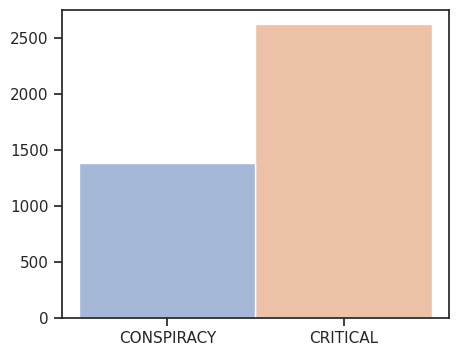

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.set_theme(style="ticks")
sns.histplot(data=data, x='category', hue='category', legend=False)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['text'], data['category'], test_size=0.2, random_state=42)

Codificar la variable de predicción `category` usando [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html), que por defecto cambia las categorías por números enteros.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_numerical = label_encoder.fit_transform(y_train)
y_test_numerical = label_encoder.transform(y_test)

## Clasificación usando índices

### Valores enteros como índices

En primer lugar, creamos una capa de codificación de texto con [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/).

Esta capa tiene opciones básicas para gestionar texto en un modelo de Keras. Por defecto, transforma un conjunto de cadenas en una lista de vectores (`output_mode = "int"`), en la que cada uno de estos vectores es una lista de números enteros correspondientes a los índices de tokens.

- Crear [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), especificando diversos parámetros.
- Aplicar [`adapt()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization#adapt) para construir el diccionario a partir de datos.

In [ ]:
from keras.layers import TextVectorization

vectorizer = TextVectorization(
    max_tokens=20000,
    standardize="lower_and_strip_punctuation",
    output_mode="int",
    output_sequence_length=10)

vectorizer.adapt(X_train)

Podemos recuperar el vocabulario completo construido.

In [ ]:
vectorizer.get_vocabulary()[:10]

['', '[UNK]', 'the', 'to', 'of', 'and', 'a', 'in', 'is', 'for']

De esta forma, esta capa puede codificar secuencias de texto. Podemos usarla de forma aislada o dentro de un modelo.

In [ ]:
input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)

<tf.Tensor: shape=(2, 10), dtype=int64, numpy=
array([[  13, 4629,  235, 1133, 8583, 1340, 1157,    0,    0,    0],
       [   6,  871,   12,   40, 1292,   26,   86,    0,    0,    0]])>

Usando la capa de [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), podemos crear y entrenar un modelo de clasificación.

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

vectorizer = TextVectorization(
    max_tokens=20000,
    output_sequence_length=100)
vectorizer.adapt(X_train)

model_indices = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

In [ ]:
model_indices.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_indices.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=50,
    validation_split=0.2)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5380 - loss: 629.5789 - val_accuracy: 0.5906 - val_loss: 324.8468
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5849 - loss: 276.3525 - val_accuracy: 0.6000 - val_loss: 265.5454
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6150 - loss: 203.1832 - val_accuracy: 0.6156 - val_loss: 263.1701
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6621 - loss: 132.9467 - val_accuracy: 0.5922 - val_loss: 243.7545
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6700 - loss: 106.9439 - val_accuracy: 0.5828 - val_loss: 225.6438
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7020 - loss: 80.7015 - val_accuracy: 0.5969 - val_loss: 211.4260
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7445 - loss: 57.9176 - val_accuracy: 0.5844 - val_loss: 210.0266
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7524 - loss: 50.3117

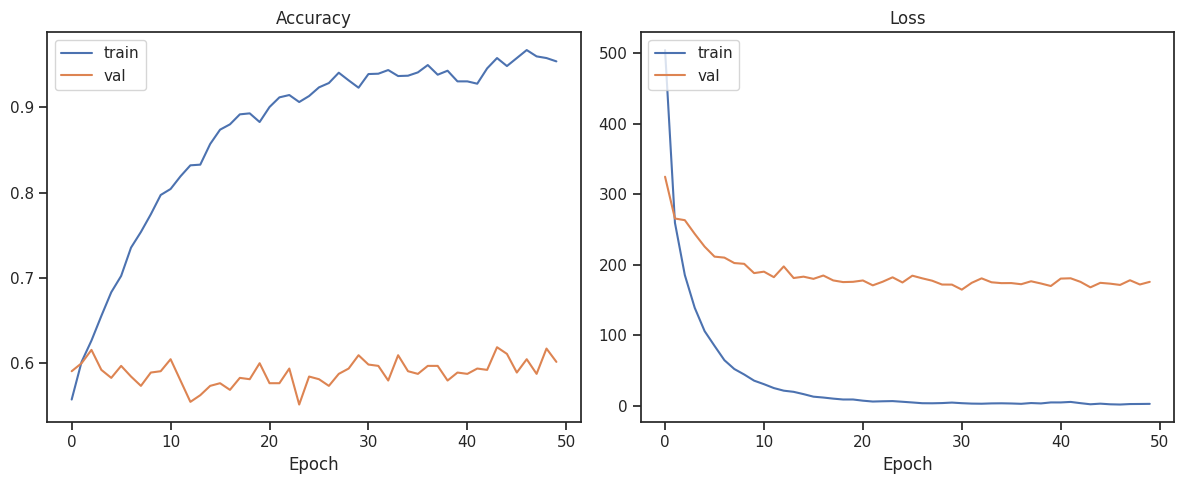

In [ ]:
# Creamos una función para crear las gráficas que reutilizaremos en adelante
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')

    # Loss
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history)

### Codificaciones one-hot y tf-idf

Podemos utilizar otro tipo de codificaciones con la misma capa [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/); por ejemplo, one-hot o tf-idf.

In [ ]:
# Ejemplo de codificación tipo one-hot
vectorizer = TextVectorization(
    max_tokens=20000,
    output_mode="multi_hot")
vectorizer.adapt(X_train)

input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)
pd.DataFrame(vectorizer(input_data).numpy(), columns=vectorizer.get_vocabulary())

,[UNK],the,to,of,and,a,in,is,for,that,...,2816,2814,2800000,280,27s,2796427,2794886,2791253,2780342438778873,27793
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Y entrenar un modelo de clasificación de la forma habitual.

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7513 - loss: 0.5567 - val_accuracy: 0.8531 - val_loss: 0.3613
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9581 - loss: 0.1685 - val_accuracy: 0.8609 - val_loss: 0.3620
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9910 - loss: 0.0688 - val_accuracy: 0.8703 - val_loss: 0.3774
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9952 - loss: 0.0339 - val_accuracy: 0.8703 - val_loss: 0.4061
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9971 - loss: 0.0242 - val_accuracy: 0.8672 - val_loss: 0.4236
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.8609 - val_loss: 0.4488
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9998 - loss: 0.0079 - val_accuracy: 0.8656 - val_loss: 0.4685
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9999 - loss: 0.0052 - val_accuracy: 0.8656 - v

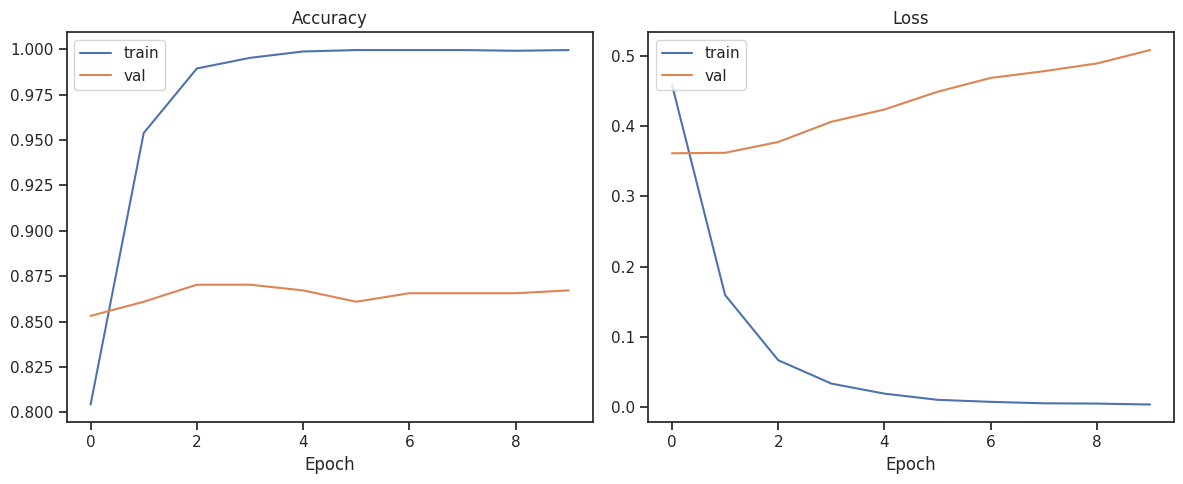

In [ ]:
# Modelo one-hot
model_onehot = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_onehot.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_onehot.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=10,
    validation_split=0.2)

plot_training_history(history)

In [ ]:
# Ejemplo de codificación tipo tf-idf
vectorizer = TextVectorization(
    max_tokens=20000,
    output_mode="tf-idf")
vectorizer.adapt(X_train)

input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)
pd.DataFrame(vectorizer(input_data).numpy(), columns=vectorizer.get_vocabulary())

,[UNK],the,to,of,and,a,in,is,for,that,...,2816,2814,2800000,280,27s,2796427,2794886,2791253,2780342438778873,27793
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.019169,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7611 - loss: 0.5121 - val_accuracy: 0.8219 - val_loss: 0.4350
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9894 - loss: 0.0724 - val_accuracy: 0.8469 - val_loss: 0.5251
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9982 - loss: 0.0199 - val_accuracy: 0.8469 - val_loss: 0.5840
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9987 - loss: 0.0107 - val_accuracy: 0.8406 - val_loss: 0.6177
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9991 - loss: 0.0102 - val_accuracy: 0.8484 - val_loss: 0.6881
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9988 - loss: 0.0042 - val_accuracy: 0.8391 - val_loss: 0.6907
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.8453 - val_loss: 0.7322
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8453 - val_lo

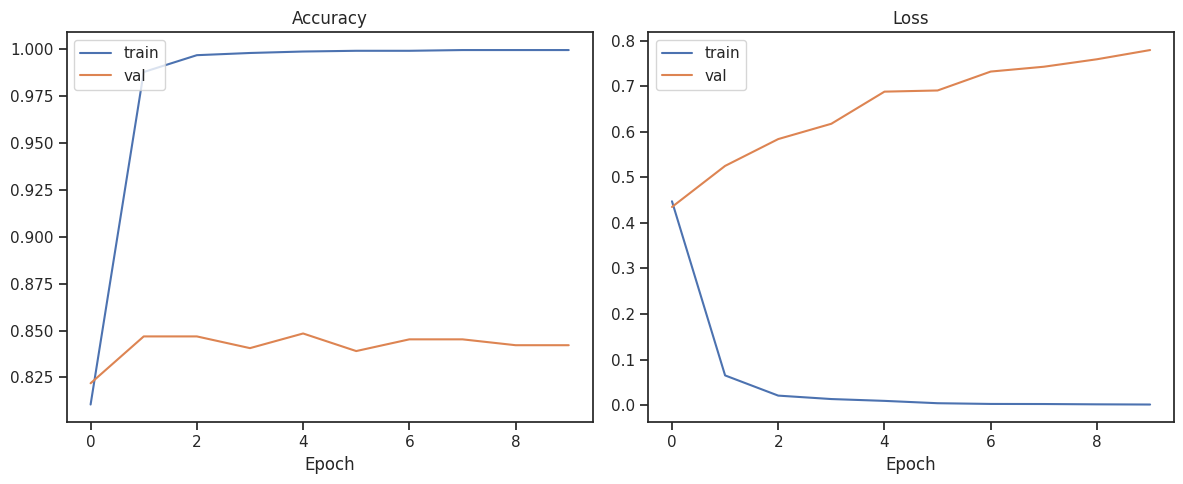

In [ ]:
# Modelo tf-idf
model_tfidf = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_tfidf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_tfidf.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=10,
    validation_split=0.2)

plot_training_history(history)

## Clasificación usando _embeddings_

### Entrenando una capa de _embeddings_

Podemos utilizar una capa de [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) para que la red aprenda una representación de los tokens optimizada para este problema.



Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6893 - loss: 0.5995 - val_accuracy: 0.8109 - val_loss: 0.4107
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9559 - loss: 0.1352 - val_accuracy: 0.8375 - val_loss: 0.4205
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0087 - val_accuracy: 0.8406 - val_loss: 0.4463
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 0.8438 - val_loss: 0.4357
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9987 - loss: 0.0018 - val_accuracy: 0.8422 - val_loss: 0.4549


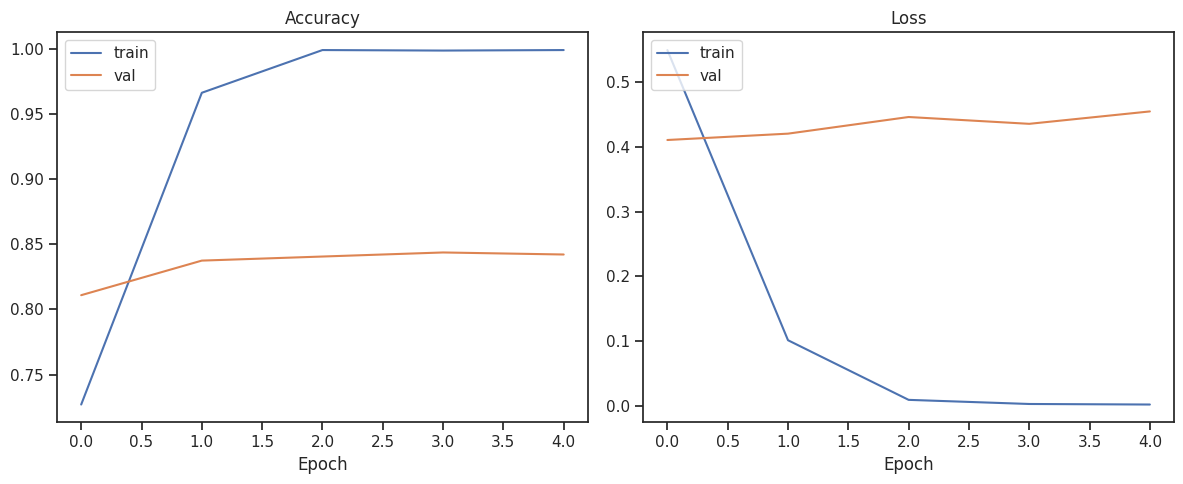

In [ ]:
from keras.layers import Embedding, Flatten, Input
from keras.models import Model

max_length = 100
max_tokens = 20000

vectorizer = TextVectorization(
  max_tokens=max_tokens,
  output_mode="int",
  output_sequence_length=max_length,
)
vectorizer.adapt(X_train)

model_embedding = Sequential([
    Embedding(input_dim=max_tokens, output_dim=256),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_embedding.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

X_train_numerical = vectorizer(tf.convert_to_tensor(X_train))
history = model_embedding.fit(
    X_train_numerical,
    y_train_numerical,
    epochs=5,
    validation_split=0.2
)

plot_training_history(history)

### Usando _embeddings_ precalculados

El proceso anterior es lento. En lugar de entrenar nuestra propia capa [`Embedding`](https://keras.io/api/layers/core_layers/embedding/), podemos usar _embeddings_ preentrenados, como por ejemplo [Glove](https://nlp.stanford.edu/projects/glove/). Para ello, necesitamos:

* Preparar el `vectorizer`
* Descargar Glove
* Preparar los valores descargados para insertarlos como pesos en la capa [`Embedding`](https://keras.io/api/layers/core_layers/embedding/)
  * Crear diccionario token -> embedding
  * Crear matriz de embeddings
* Crear el modelo especificando estos pesos
* Entrenar el modelo

In [ ]:
# Preparar el vectorizer
vectorizer = TextVectorization(
  max_tokens=max_tokens,
  output_mode="int",
  output_sequence_length=max_length,
)

vectorizer.adapt(X_train)

In [ ]:
# Descargar GloVe
import os
import urllib.request
import zipfile

glove_url  = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_path = "glove.6B.zip"
glove_dir  = "glove"

if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(glove_url, glove_path)

# Extraer fichero
if not os.path.exists(glove_dir):
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(glove_path, "r") as zip_ref:
        zip_ref.extractall(glove_dir)

print("GloVe embeddings are ready!")

Extracting GloVe embeddings...
GloVe embeddings are ready!


In [ ]:
import numpy as np
from tqdm import tqdm

# Crear diccionario de embeddings, mostrando las 5 primeras líneas del fichero
embedding_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf-8') as f:

    # Contar número de líneas y mostrar las 5 primeras
    num_lines = 0
    for i, line in enumerate(f):
        if i < 5:
            print(line.strip())
        num_lines += 1
    f.seek(0)

    # Crear diccionario token -> embedding
    for i, line in enumerate(tqdm(f, desc="Reading GloVe file", total=num_lines)):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Crear la matriz de embeddings
embedding_dim = 100
vocab_size = len(vectorizer.get_vocabulary())
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for i, word in enumerate(tqdm(vectorizer.get_vocabulary(), desc="Processing vocabulary")):
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062
, -0.10767 0.11053 0.59812 -0.54361 0.67396 0.10663 0.038867 0.35481 0.06351 -0.094189 0.15786 -0.81665 0.14172 0.21939 0.58505 -0.52158 

Processing vocabulary: 100%|██████████| 20000/20000 [00:00<00:00, 537714.05it/s]


In [ ]:
# Construir el modelo usando la matriz de embeddings
model_glove = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6780 - loss: 0.6142 - val_accuracy: 0.7422 - val_loss: 0.5010
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8567 - loss: 0.3379 - val_accuracy: 0.7250 - val_loss: 0.5264
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9564 - loss: 0.1594 - val_accuracy: 0.7500 - val_loss: 0.5754
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9959 - loss: 0.0614 - val_accuracy: 0.7203 - val_loss: 0.6997
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9994 - loss: 0.0253 - val_accuracy: 0.7297 - val_loss: 0.7565


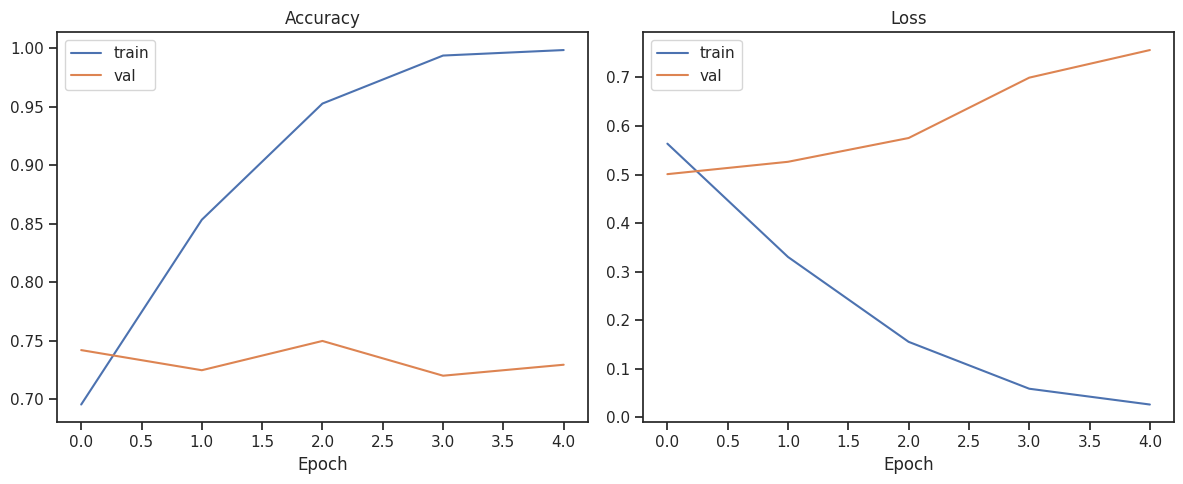

In [ ]:
# Entrenar el modelo
X_train_numerical = vectorizer(tf.convert_to_tensor(X_train))
history = model_glove.fit(
    X_train_numerical,
    y_train_numerical,
    epochs=5,
    validation_split=0.2
)

plot_training_history(history)

### Usando _embeddings_ procedentes de un modelo de lenguaje
Los modelos de lenguaje actuales suelen incluir una sección de generación de _embeddings_. Muchos de estos modelos ofrecen la posibilidad de consultar el _embedding_ para una un token o para una frase completa.

En este ejemplo, usamos [`SentenceTransformer`](https://sbert.net/) para generar los _embeddings_. Esta aproximación es más sencilla que la anterior para GloVe, ya que disponemos de utilidades para interactuar con los modelos.

In [ ]:
from sentence_transformers import SentenceTransformer

# Cargar el modelo preentrenado
transformer = SentenceTransformer('all-MiniLM-L6-v2')

# Generar embeddings para los datos de entrenamiento
X_train_embeddings = transformer.encode(X_train.tolist())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

En este caso es especialmente interesante visualizar los _embeddings_. Para ello, reducimos la dimensionalidad a 2 usando [UMAP](https://umap-learn.readthedocs.io/en/latest/) y dibujamos en dos dimensiones.

In [ ]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_train_2d = reducer.fit_transform(X_train_embeddings)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


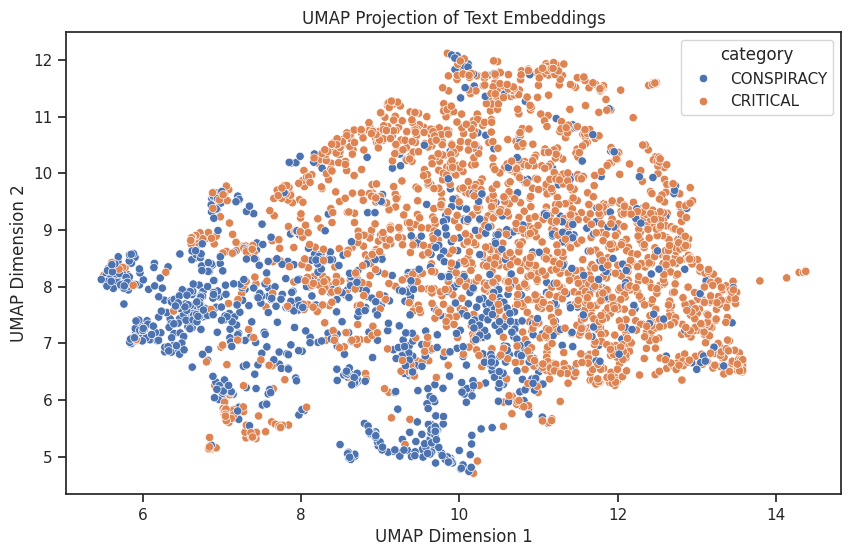

In [ ]:
import seaborn as sns

df_embeddings = pd.DataFrame(X_train_2d, columns=['UMAP Dimension 1', 'UMAP Dimension 2'])
df_embeddings['category'] = y_train.tolist()

plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")
sns.scatterplot(x='UMAP Dimension 1', y='UMAP Dimension 2', hue='category', data=df_embeddings)
plt.title('UMAP Projection of Text Embeddings')
plt.show()

Finalmente, con los _embeddings_ obtenidos podemos entrenar un nuevo modelo.

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6773 - loss: 0.6134 - val_accuracy: 0.8078 - val_loss: 0.4500
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8178 - loss: 0.4161 - val_accuracy: 0.8250 - val_loss: 0.3822
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.3579 - val_accuracy: 0.8406 - val_loss: 0.3645
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8462 - loss: 0.3472 - val_accuracy: 0.8516 - val_loss: 0.3521
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8628 - loss: 0.3209 - val_accuracy: 0.8594 - val_loss: 0.3425
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8574 - loss: 0.3268 - val_accuracy: 0.8609 - val_loss: 0.3379
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8699 - loss: 0.3153 - val_accuracy: 0.8625 - val_loss: 0.3362
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8757 - loss: 0.3016 - val_accuracy: 0.8625 - val_loss:

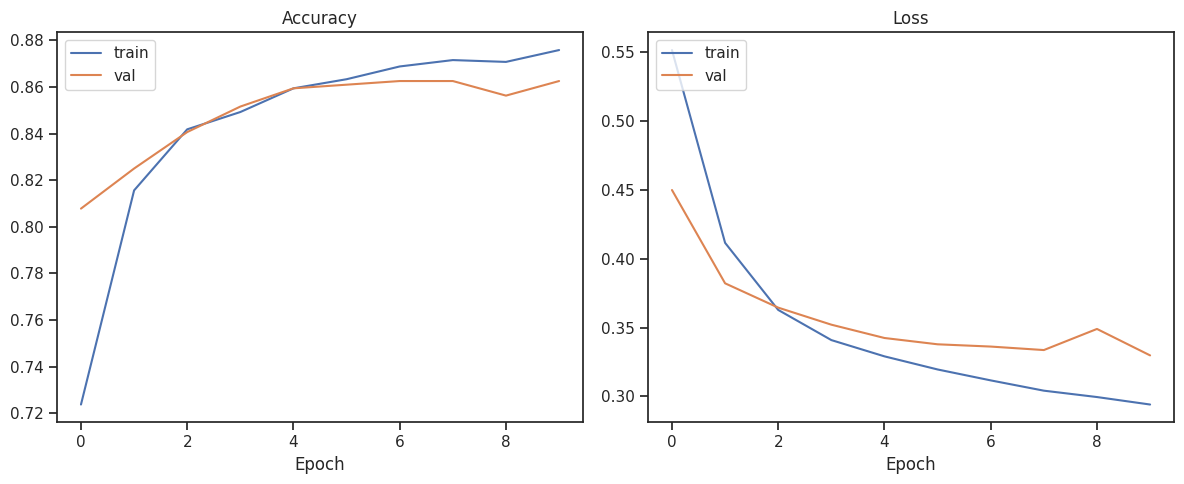

In [ ]:
model_transformer = Sequential([
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_transformer.fit(
    X_train_embeddings,
    y_train_numerical,
    epochs=15,
    validation_split=0.2)

plot_training_history(history)

## Análisis de sentimientos como clasificación

En el siguiente código, utilizamos las bibliotecas [spaCy](https://spacy.io/) y [Hugging Face](https://huggingface.co/) para realizar análisis de sentimientos.

Primero, cargamos el modelo de lenguaje en inglés de spaCy, que nos permite procesar texto y realizar tareas de procesamiento de lenguaje natural. A continuación, cargamos un pipeline de análisis de sentimientos de Hugging Face, específicamente el modelo [`cardiffnlp/twitter-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment). Este pipeline nos ayuda a determinar el sentimiento de un texto, clasificándolo como positivo, negativo o neutral (LABEL_0 -> Negative; LABEL_1 -> Neutral; LABEL_2 -> Positive).

La función `analyze_sentiment` toma una frase como entrada y utiliza el pipeline para obtener la etiqueta de sentimiento y su puntuación de confianza. Si el texto es demasiado largo, se trunca a 512 caracteres para evitar errores de procesamiento. Finalmente, aplicamos esta función a cada texto en la columna 'text' de nuestro conjunto de datos, almacenando los resultados en un nuevo DataFrame.

In [ ]:
import spacy
from transformers import pipeline

# Cargar el modelo de spaCy
nlp = spacy.load("en_core_web_sm")

# Cargar el pipeline de análisis de sentimientos de Hugging Face
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment")

# Función para realizar análisis de sentimientos en una frase
def analyze_sentiment(sentence):
    try:
        result = sentiment_pipeline(sentence)[0]
        return result['label'], result['score']
    except Exception as e:
        print(f"Error analizando el sentimiento para '{sentence}': {e}")
        return "UNKNOWN", 0.0

# Aplicar análisis de sentimientos a cada frase en la columna 'text', truncando a 512 si supera esta longitud
sentiment_labels = []
sentiment_scores = []

for text in data['text']:
    truncated_text = text[:512] if len(text) > 512 else text
    sentiment_label, sentiment_score = analyze_sentiment(truncated_text)
    sentiment_labels.append(sentiment_label)
    sentiment_scores.append(sentiment_score)

data_sentiment = pd.DataFrame({
    'text': data['text'],
    'category': data['category'],
    'sentiment_label': [label.replace('LABEL_0', 'Negative').replace('LABEL_1', 'Neutral').replace('LABEL_2', 'Positive') for label in sentiment_labels],
    'sentiment_score': sentiment_scores
})

data_sentiment

Device set to use cuda:0


,text,category,sentiment_label,sentiment_score
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY,Negative,0.609890
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL,Negative,0.791545
2,2021 : They wanted to know your vaccination st...,CRITICAL,Negative,0.659615
3,Anthony Fauci once again defended brutal Chine...,CRITICAL,Neutral,0.511057
4,Proof has emerged showing that death from Wuha...,CRITICAL,Negative,0.484783
...,...,...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL,Negative,0.865195
3996,I personally do n’t believe Putin would set of...,CONSPIRACY,Negative,0.528019
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL,Neutral,0.509923
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL,Negative,0.583312


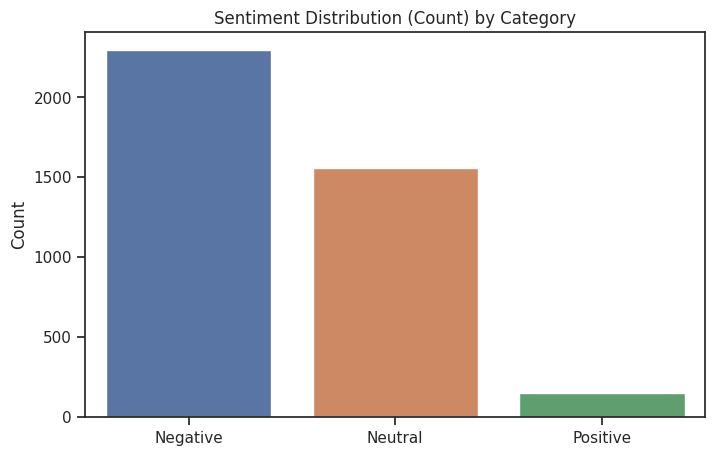

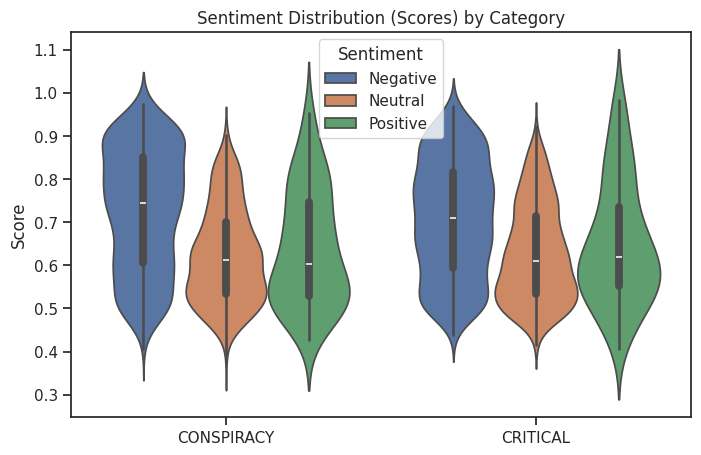

In [46]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.countplot(data=data_sentiment, x='sentiment_label', hue='sentiment_label', order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Distribution (Count) by Category')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

# Crear un gráfico de violín para mostrar la distribución de las puntuaciones de sentimiento por categoría
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.violinplot(data=data_sentiment, x='category', y='sentiment_score', hue='sentiment_label')
plt.title('Sentiment Distribution (Scores) by Category')
plt.xlabel('')
plt.ylabel('Score')
plt.legend(title='Sentiment')
plt.show()


## Clasificación con LLMs

En esta sección, se utiliza el modelo de lenguaje de OpenAI, ChatGPT, para clasificar textos en dos categorías: `CONSPIRACY` o `CRITICAL`. Para acceder a este modelo, se utiliza la biblioteca [`openai`](https://platform.openai.com/docs/guides/text-generation), siguiendo el siguiente procedimiento.

Primero, se solicita al usuario que introduzca su clave de API de OpenAI para autenticar las solicitudes al servicio.

Después, se define una función llamada `classify_text_with_chatgpt` que toma un texto como entrada y utiliza el modelo de lenguaje para clasificarlo. La función envía una solicitud al modelo con un prompt que le pide clasificar el texto en una de las dos categorías.

Si la clasificación es exitosa, se devuelve la categoría; de lo contrario, se maneja cualquier excepción y se devuelve `UNKNOWN`. Finalmente, se aplica esta función a cada texto en la columna 'text' de los datos, almacenando los resultados en un nuevo DataFrame llamado `data_classification`.

In [ ]:
from openai import OpenAI
import getpass

# Solicitar la clave de API de OpenAI al usuario
my_api_key = getpass.getpass("Por favor, introduce tu clave de API de OpenAI: ")

# Inicializar cliente
client = OpenAI(api_key=my_api_key)

# Función para clasificar texto utilizando ChatGPT
def classify_text_with_chatgpt(text):
    try:
        response = client.chat.completions.create(
            model="gpt-4",
            messages=[{
                "role": "developer",
                "content": f"Classify the following text as CONSPIRACY or CRITICAL: {text}. "}]
        )
        classification = response.choices[0].message.content.strip()
        return classification
    except Exception as e:
        print(f"Error while classifying the text '{text}': {e}")
        return "UNKNOWN"

# Aplicar clasificación a cada texto en la columna 'text'
# (limitado a los `limit` primeros mensajes)
classifications = []
limit = 25

for text in tqdm(data['text'][:limit], desc="Classifying texts"):
    classification = classify_text_with_chatgpt(text)
    classifications.append(classification)

# Crear DataFrame con los resultados
data_classification = pd.DataFrame({
    'text': data['text'][:limit],
    'real_category': data['category'][:limit],
    'llm_classification': classifications
})

data_classification

Por favor, introduce tu clave de API de OpenAI: ··········


Classifying texts: 100%|██████████| 25/25 [00:20<00:00,  1.19it/s]


,text,real_category,llm_classification
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL,CONSPIRACY
3,Anthony Fauci once again defended brutal Chine...,CRITICAL,CONSPIRACY
4,Proof has emerged showing that death from Wuha...,CRITICAL,CONSPIRACY
5,"Joe Biden , who told Americans last year , “ Y...",CRITICAL,CRITICAL
6,""" 1861 for a number of black - magick - relate...",CONSPIRACY,CONSPIRACY
7,WHAT THE HELL HAVE THEY DONE ? FOREIGN PARTICL...,CRITICAL,CONSPIRACY
8,Joe Biden ’s Commerce Secretary has claimed th...,CRITICAL,CRITICAL
9,""" COVID : ALLEGED DOCUMENT PREDICTING THE FREN...",CRITICAL,CONSPIRACY
